In [3]:
import yfinance as yf
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import requests

#FRED API key
FRED_API_KEY = "9c8fc527d67434da47bc1842ddbd7a59"

# Download TSLA data
tsla = yf.download("TSLA", start="2020-01-01", end="2024-12-31")
tsla = tsla['Close'].squeeze()
tsla.name = 'TSLA'
print("TSLA data loaded:", tsla.shape)

# Download 10-Year Treasury Yield from FRED
url = f"https://api.stlouisfed.org/fred/series/observations?series_id=DGS10&observation_start=2020-01-01&observation_end=2024-12-31&api_key={FRED_API_KEY}&file_type=json"
response = requests.get(url)
fred_data = response.json()

# The FRED API returns raw JSON data which needs to be converted into a 
# structured pandas DataFrame for analysis. I extract just the date and 
# value columns, convert the date strings to proper datetime objects so 
# they can be matched with TSLA trading dates, and convert the yield values 
# to numeric floats. The errors='coerce' argument handles any non-numeric 
# values like '.' which FRED uses to represent missing observations on 
# holidays or weekends, converting them to NaN so they can be dropped cleanly.
yields = pd.DataFrame(fred_data['observations'])[['date', 'value']]
yields['date'] = pd.to_datetime(yields['date'])
yields['value'] = pd.to_numeric(yields['value'], errors='coerce')
yields = yields.dropna().set_index('date')
yields.columns = ['Yield_10Y']
print("Yield data loaded:", yields.shape)

[*********************100%***********************]  1 of 1 completed


TSLA data loaded: (1257,)
Yield data loaded: (1251, 1)


In [16]:
# ===== DATA CLEANING =====

# Check for missing values before cleaning
print("=== Missing Values Before Cleaning ===")
print(f"TSLA missing values: {tsla.isnull().sum()}")
print(f"Yield missing values: {yields.isnull().sum()}")

# Check for duplicate dates
print(f"\nTSLA duplicate dates: {tsla.index.duplicated().sum()}")
print(f"Yield duplicate dates: {yields.index.duplicated().sum()}")

# Check date range
print(f"\nTSLA date range: {tsla.index.min()} to {tsla.index.max()}")
print(f"Yield date range: {yields.index.min()} to {yields.index.max()}")

# Check for any zero or negative prices in TSLA (would indicate bad data)
print(f"\nTSLA zero/negative prices: {(tsla <= 0).sum()}")

# After merging the two datasets I want to verify the quality of the combined
# data before doing any analysis. I check the shape to confirm we have a 
# reasonable number of overlapping trading days, check for any missing values
# that may have been introduced during the merge, and confirm all columns are
# the correct float64 data type for numerical analysis. This step is important
# because errors caught here prevent misleading results downstream.
print(f"\n=== After Merging ===")
print(f"Merged shape: {df.shape}")
print(f"Missing values in merged dataset:\n{df.isnull().sum()}")
print(f"\nData types:\n{df.dtypes}")
# Drop the first row NaN created by pct_change()
df = df.dropna()
print(f"Final clean dataset shape: {df.shape}")
# TSLA price and the 10-Year yield are measured in completely different units
# - one is in dollars (ranging from $30 to $480) and the other is a percentage
# (ranging from 0.5% to 5%). To make them directly comparable in analysis I
# apply MinMax normalization which scales both series to a 0-1 range where
# 0 represents the minimum value and 1 represents the maximum over the period.
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()
df[['TSLA_Normalized', 'Yield_Normalized']] = scaler.fit_transform(df[['TSLA', 'Yield_10Y']])

print("Normalization complete")
print(df[['TSLA_Normalized', 'Yield_Normalized']].describe())

=== Missing Values Before Cleaning ===
TSLA missing values: 0
Yield missing values: Yield_10Y    0
dtype: int64

TSLA duplicate dates: 0
Yield duplicate dates: 0

TSLA date range: 2020-01-02 00:00:00 to 2024-12-30 00:00:00
Yield date range: 2020-01-02 00:00:00 to 2024-12-31 00:00:00

TSLA zero/negative prices: 0

=== After Merging ===
Merged shape: (1158, 7)
Missing values in merged dataset:
TSLA             0
Yield_10Y        0
Returns_TSLA     0
Returns_Yield    0
Volatility_30    0
MA90             0
Regime           0
dtype: int64

Data types:
TSLA             float64
Yield_10Y        float64
Returns_TSLA     float64
Returns_Yield    float64
Volatility_30    float64
MA90             float64
Regime             int64
dtype: object
Final clean dataset shape: (1158, 7)
Normalization complete
       TSLA_Normalized  Yield_Normalized
count      1158.000000       1158.000000
mean          0.406410          0.512671
std           0.166458          0.307064
min           0.000000          0

In [4]:
# Merge datasets on date
df = pd.merge(tsla, yields, left_index=True, right_index=True, how='inner')
df.columns = ['TSLA', 'Yield_10Y']
df = df.dropna()
print("Merged dataset shape:", df.shape)
print(df.head())

Merged dataset shape: (1248, 2)
                 TSLA  Yield_10Y
Date                            
2020-01-02  28.684000       1.88
2020-01-03  29.534000       1.80
2020-01-06  30.102667       1.81
2020-01-07  31.270666       1.83
2020-01-08  32.809334       1.87


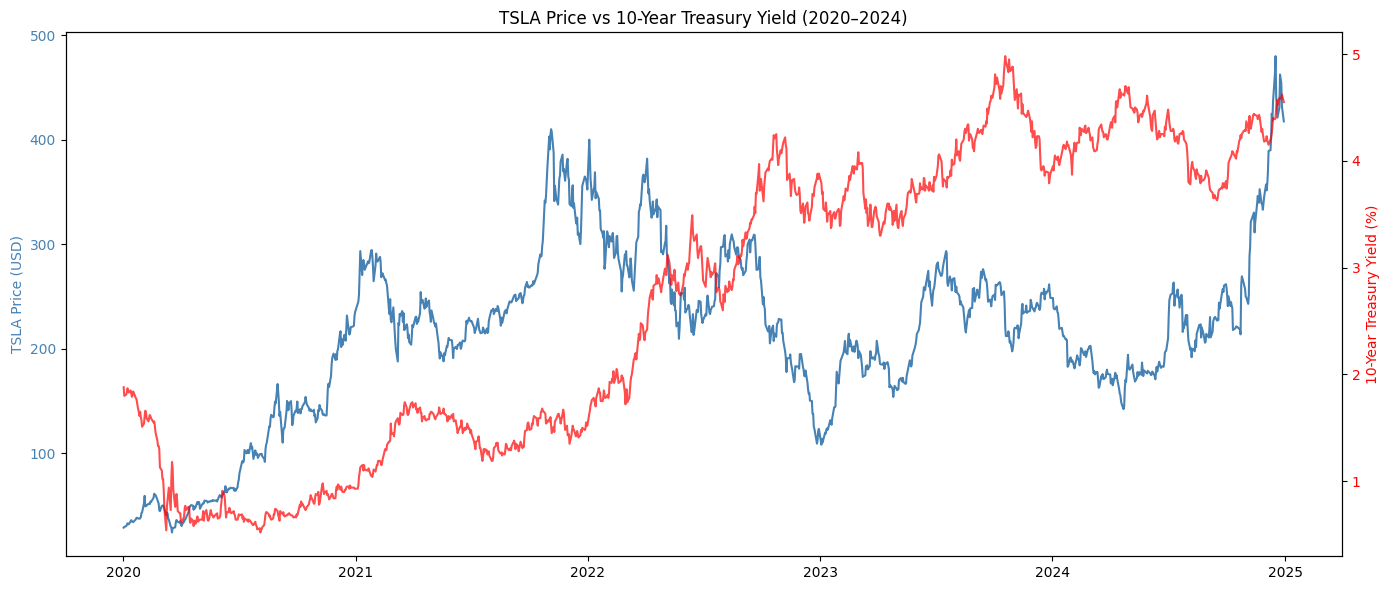

In [5]:
# Plot TSLA price and 10Y yield together
fig, ax1 = plt.subplots(figsize=(14, 6))

# TSLA on left axis
ax1.plot(df.index, df['TSLA'], color='steelblue', label='TSLA Price')
ax1.set_ylabel('TSLA Price (USD)', color='steelblue')
ax1.tick_params(axis='y', labelcolor='steelblue')

# Yield on right axis
ax2 = ax1.twinx()
ax2.plot(df.index, df['Yield_10Y'], color='red', label='10Y Treasury Yield', alpha=0.7)
ax2.set_ylabel('10-Year Treasury Yield (%)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

plt.title('TSLA Price vs 10-Year Treasury Yield (2020–2024)')
fig.tight_layout()
plt.show()

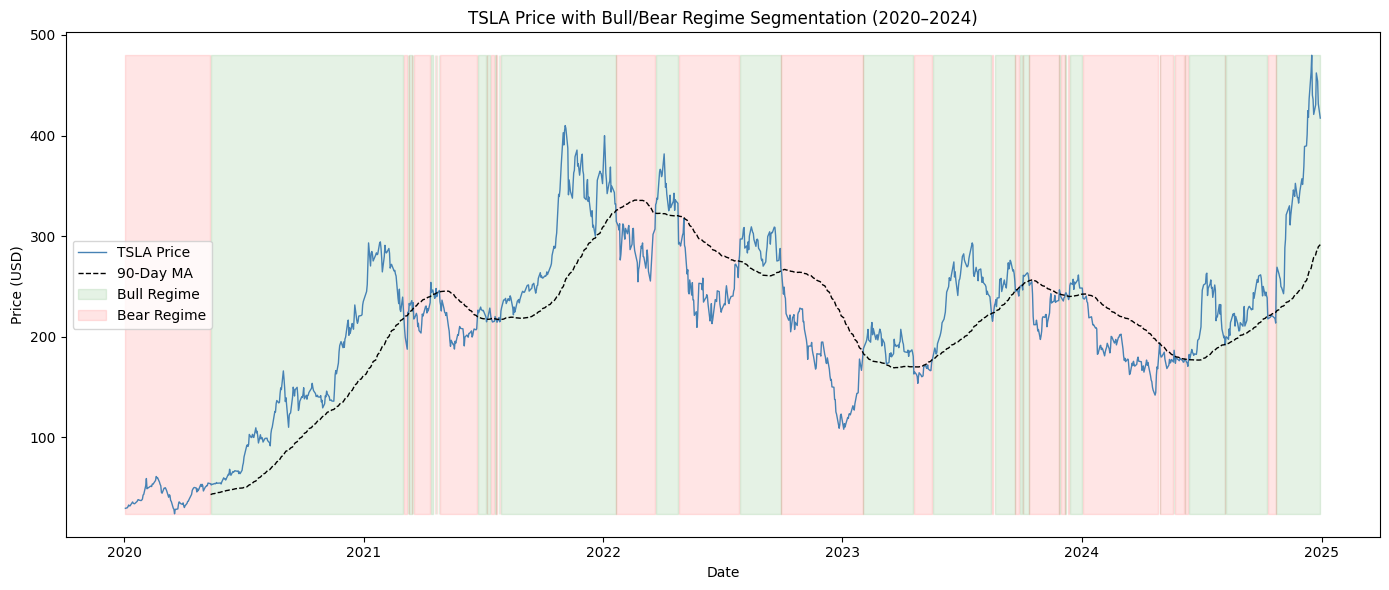

In [14]:
# To segment the data into meaningful market regimes I use the 90-day moving
# average as a threshold. When TSLA's price is above its 90-day MA the stock
# is in an uptrend and I label it a bull regime (1), when below I label it a
# bear regime (0). I chose 90 days specifically because it is long enough to
# filter out short term noise and weekly fluctuations while still being
# responsive enough to capture major trend shifts like the 2022 rate hike
# selloff. A shorter window like 30 days produced too many false signals.
df['MA90'] = df['TSLA'].rolling(window=90).mean()
df['Regime'] = (df['TSLA'] > df['MA90']).astype(int)

# Plot with regimes highlighted
plt.figure(figsize=(14, 6))
plt.plot(df['TSLA'], color='steelblue', label='TSLA Price', linewidth=1)
plt.plot(df['MA90'], color='black', linestyle='--', label='90-Day MA', linewidth=1)

# Shade bull and bear periods
plt.fill_between(df.index, df['TSLA'].min(), df['TSLA'].max(),
                 where=df['Regime']==1, alpha=0.1, color='green', label='Bull Regime')
plt.fill_between(df.index, df['TSLA'].min(), df['TSLA'].max(),
                 where=df['Regime']==0, alpha=0.1, color='red', label='Bear Regime')

plt.title('TSLA Price with Bull/Bear Regime Segmentation (2020–2024)')
plt.xlabel('Date')
plt.ylabel('Price (USD)')
plt.legend()
plt.tight_layout()
plt.show()

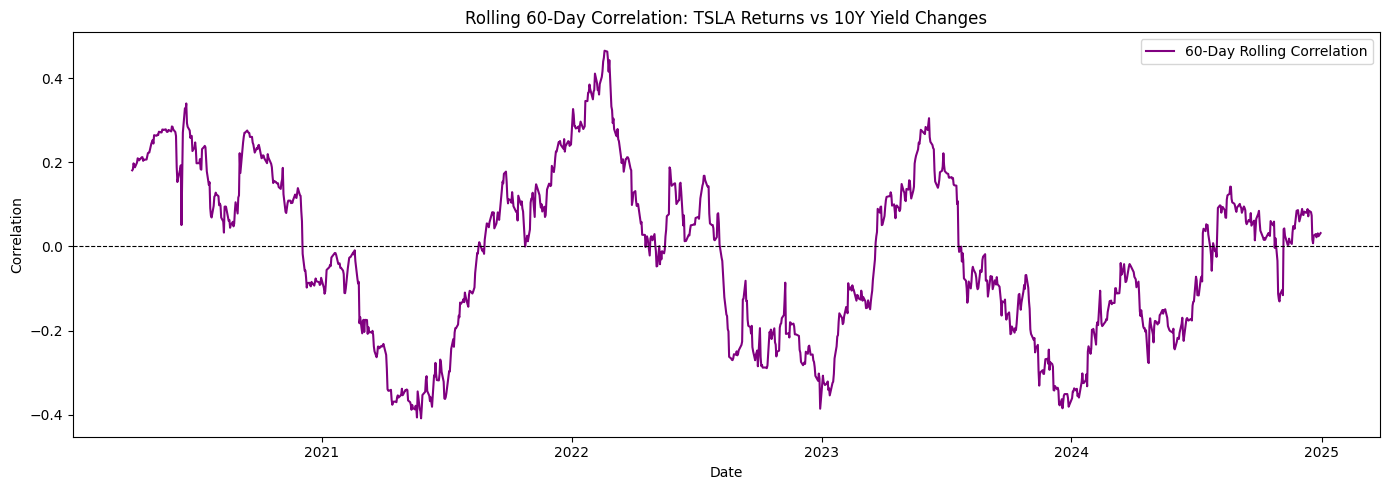

In [6]:
# To understand how the relationship between TSLA and Treasury yields evolves
# over time I calculate a rolling 60-day correlation between their daily returns.
# Rather than computing a single static correlation for the entire 5 year period
# which would hide important changes, the rolling window lets me see exactly
# when the relationship strengthened or weakened. I chose 60 days because it
# covers roughly 3 months of trading - long enough to be statistically meaningful
# but short enough to capture shifts in market dynamics like the onset of the
# 2022 rate hike cycle.df['Returns_TSLA'] = df['TSLA'].pct_change()
df['Returns_Yield'] = df['Yield_10Y'].pct_change()

rolling_corr = df['Returns_TSLA'].rolling(window=60).corr(df['Returns_Yield'])

plt.figure(figsize=(14, 5))
plt.plot(rolling_corr, color='purple', label='60-Day Rolling Correlation')
plt.axhline(0, color='black', linestyle='--', linewidth=0.8)
plt.title('Rolling 60-Day Correlation: TSLA Returns vs 10Y Yield Changes')
plt.ylabel('Correlation')
plt.xlabel('Date')
plt.legend()
plt.tight_layout()
plt.show()

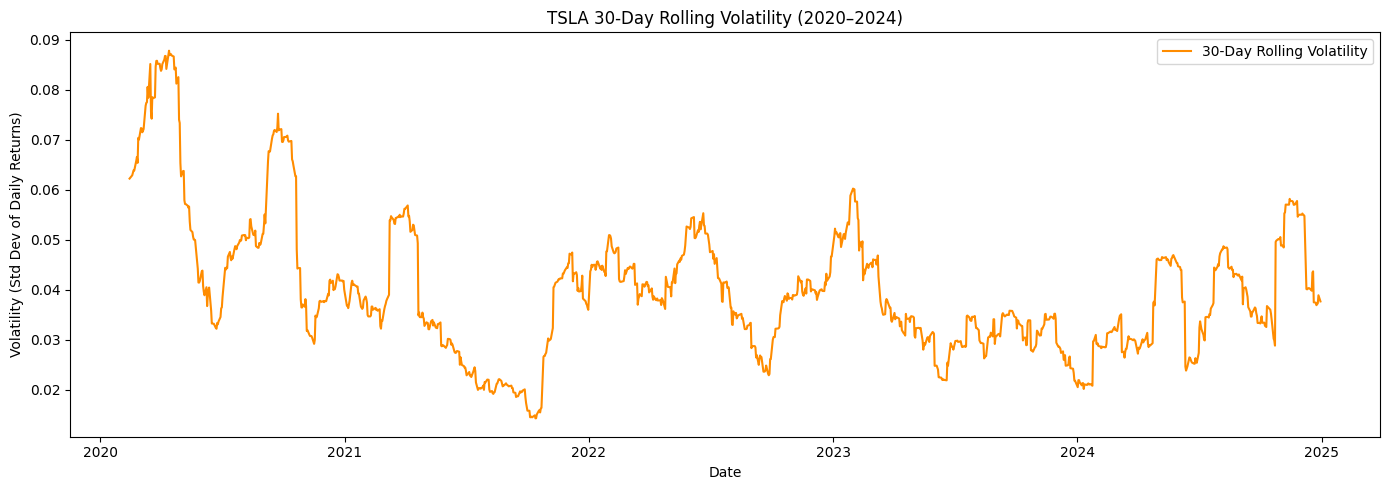

In [13]:
# I calculate a 30-day rolling standard deviation of daily returns rather
# than a static measure because volatility is not constant - it clusters
# around major market events like the COVID crash or Fed announcements and
# then subsides. I chose a 30-day window because it captures roughly one
# month of trading activity which is the standard lookback period used in
# financial volatility analysis. Higher values mean the stock was experiencing
# larger and more unpredictable daily swings during that period.
df['Volatility_30'] = df['Returns_TSLA'].rolling(window=30).std()

plt.figure(figsize=(14, 5))
plt.plot(df['Volatility_30'], color='darkorange', label='30-Day Rolling Volatility')
plt.title('TSLA 30-Day Rolling Volatility (2020–2024)')
plt.xlabel('Date')
plt.ylabel('Volatility (Std Dev of Daily Returns)')
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
from statsmodels.tsa.stattools import grangercausalitytests

# Before fitting the Granger Causality test and VAR model I prepare a clean
# dataset containing only the two return series I want to analyze - TSLA daily
# returns and 10-Year yield daily changes. I use returns rather than raw prices
# because financial time series models require stationary data, meaning the
# statistical properties like mean and variance should not change over time.
# Raw prices trend upward over time which violates this assumption, but daily
# percentage changes are stationary and appropriate for modeling.
gc_data = df[['Returns_TSLA', 'Returns_Yield']].dropna()

print("=== Granger Causality Test ===")
print("Does 10Y Yield CAUSE TSLA returns?\n")
results = grangercausalitytests(gc_data[['Returns_TSLA', 'Returns_Yield']], maxlag=5, verbose=True)

=== Granger Causality Test ===
Does 10Y Yield CAUSE TSLA returns?


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=6.9585  , p=0.0084  , df_denom=1243, df_num=1
ssr based chi2 test:   chi2=6.9753  , p=0.0083  , df=1
likelihood ratio test: chi2=6.9559  , p=0.0084  , df=1
parameter F test:         F=6.9585  , p=0.0084  , df_denom=1243, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=3.9581  , p=0.0193  , df_denom=1240, df_num=2
ssr based chi2 test:   chi2=7.9482  , p=0.0188  , df=2
likelihood ratio test: chi2=7.9229  , p=0.0190  , df=2
parameter F test:         F=3.9581  , p=0.0193  , df_denom=1240, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=2.8023  , p=0.0387  , df_denom=1237, df_num=3
ssr based chi2 test:   chi2=8.4546  , p=0.0375  , df=3
likelihood ratio test: chi2=8.4260  , p=0.0380  , df=3
parameter F test:         F=2.8023  , p=0.0387  , df_denom=1237, df_num=3

Granger Causality
nu

C:\Users\andre\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


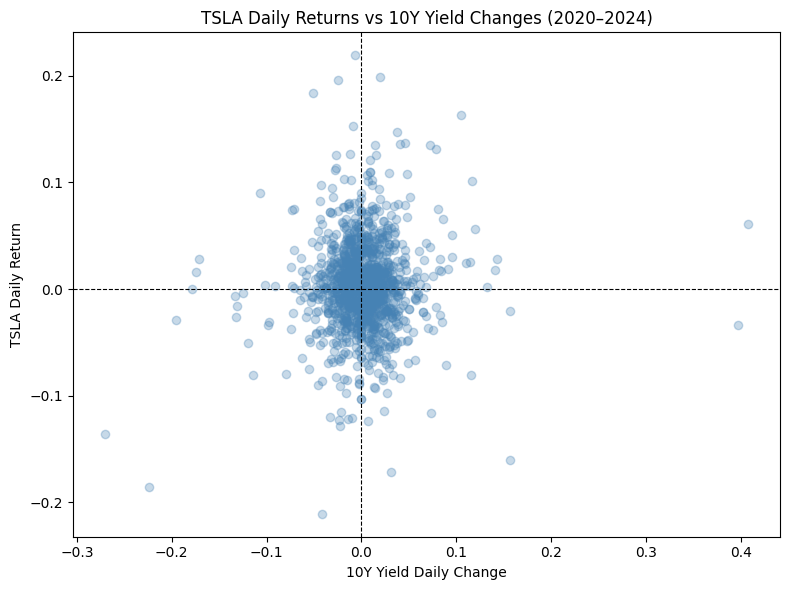

In [8]:
# Scatter plot of yield changes vs TSLA returns
plt.figure(figsize=(8, 6))
plt.scatter(df['Returns_Yield'], df['Returns_TSLA'], alpha=0.3, color='steelblue')
plt.axhline(0, color='black', linewidth=0.8, linestyle='--')
plt.axvline(0, color='black', linewidth=0.8, linestyle='--')
plt.title('TSLA Daily Returns vs 10Y Yield Changes (2020–2024)')
plt.xlabel('10Y Yield Daily Change')
plt.ylabel('TSLA Daily Return')
plt.tight_layout()
plt.show()

In [18]:
from statsmodels.tsa.api import VAR

# Prepare clean data
var_data = df[['Returns_TSLA', 'Returns_Yield']].dropna()

# I chose a Vector Autoregression (VAR) model because unlike ARIMA which models
# a single time series in isolation, VAR models two series simultaneously and
# captures how each one influences the other over time. This is the natural
# modeling choice after the Granger test confirmed a predictive relationship
# between yields and TSLA returns - VAR formalizes that relationship into a
# forecasting model. Setting maxlags=5 tells the model to consider up to 5
# days of history, and ic='aic' lets the model automatically select the optimal
# number of lags using the Akaike Information Criterion to avoid overfitting.
model = VAR(var_data)
results = model.fit(maxlags=5, ic='aic')
print(results.summary())
from sklearn.metrics import mean_absolute_error
import numpy as np

# Get actual values for last 30 days
actual_tsla = var_data['Returns_TSLA'].values[-30:]
predicted_tsla = forecast_df['TSLA_Return_Forecast'].values

# To evaluate how well the VAR model performed I compare its 30-day forecast
# against the actual TSLA returns that occurred over that period. I use two
# standard metrics - RMSE and MAE. RMSE penalizes larger errors more heavily
# because it squares the differences before averaging, making it sensitive to
# big misses. MAE treats all errors equally by taking the absolute difference.
# I also report the AIC from the model fitting stage which measures how well
# the model fits the training data relative to its complexity - a more negative
# AIC indicates a better fitting model.
rmse = np.sqrt(np.mean((actual_tsla - predicted_tsla)**2))
mae = mean_absolute_error(actual_tsla, predicted_tsla)

print("=== VAR Model Performance ===")
print(f"RMSE: {rmse:.6f}")
print(f"MAE:  {mae:.6f}")
print(f"AIC:  {results.aic:.4f}")

C:\Users\andre\AppData\Roaming\Python\Python313\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Tue, 21, Apr, 2026
Time:                     02:39:07
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -13.5569
Nobs:                     1154.00    HQIC:                  -13.6059
Log likelihood:           4610.86    FPE:                1.19706e-06
AIC:                     -13.6356    Det(Omega_mle):     1.17860e-06
--------------------------------------------------------------------
Results for equation Returns_TSLA
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.002126         0.001185            1.794           0.073
L1.Returns_TSLA         -0.021688         0.029523           -0.735           0.463
L1.Returns_Yield        -0.030760        

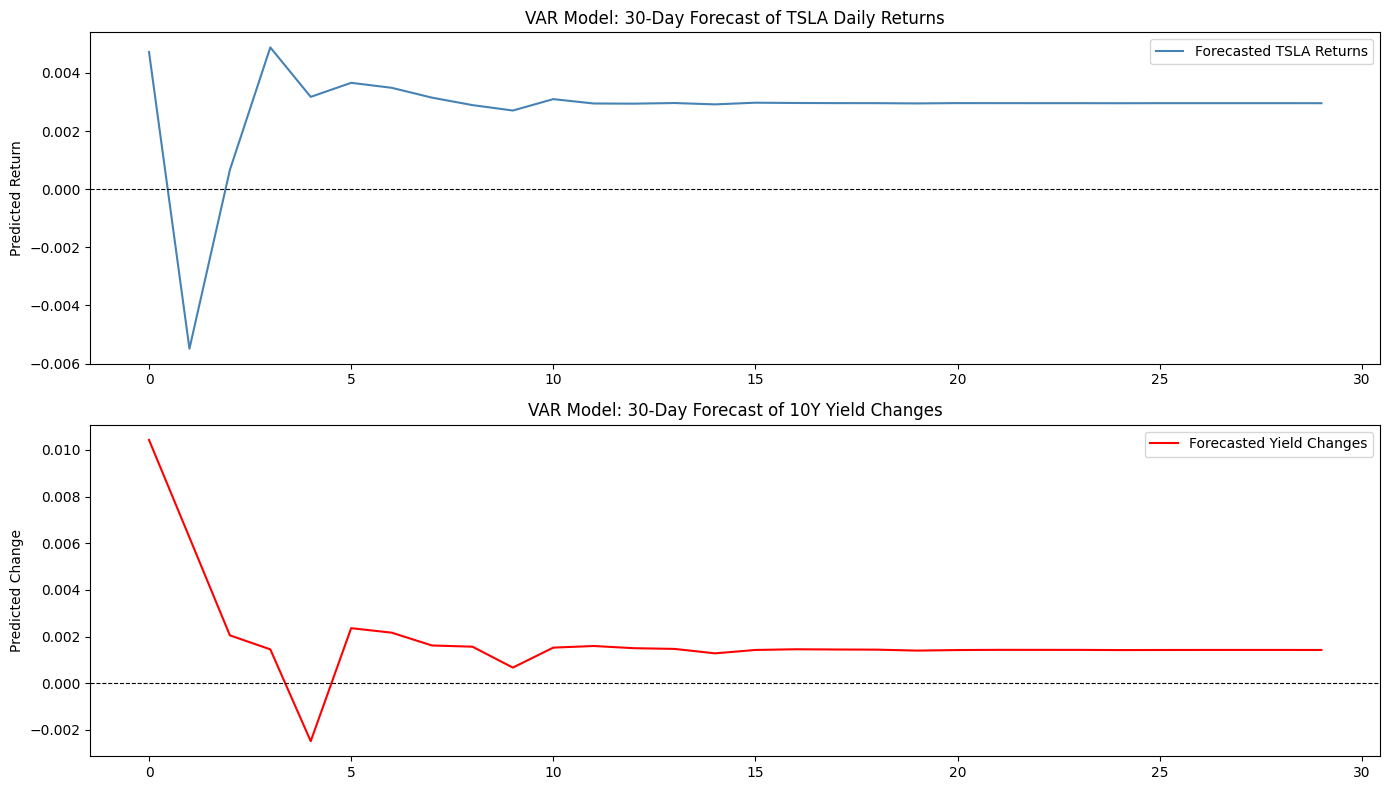

In [10]:
# Using the fitted VAR model I generate a 30-day forward forecast for both
# TSLA daily returns and 10-Year yield changes simultaneously. I feed the
# model the most recent observations equal to the lag order so it has the
# necessary history to make predictions. The forecast naturally converges
# toward zero over time which is expected behavior for a VAR model on return
# series - without new information the best long run prediction for daily
# returns is the historical mean which is close to zero. The two subplots
# show the forecasted trajectory of both variables side by side making it
# easy to see how the model expects them to evolve together.
lag_order = results.k_ar
forecast_input = var_data.values[-lag_order:]
forecast = results.forecast(forecast_input, steps=30)
forecast_df = pd.DataFrame(forecast, columns=['TSLA_Return_Forecast', 'Yield_Change_Forecast'])

# Plot
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 8))

ax1.plot(forecast_df['TSLA_Return_Forecast'], color='steelblue', label='Forecasted TSLA Returns')
ax1.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax1.set_title('VAR Model: 30-Day Forecast of TSLA Daily Returns')
ax1.set_ylabel('Predicted Return')
ax1.legend()

ax2.plot(forecast_df['Yield_Change_Forecast'], color='red', label='Forecasted Yield Changes')
ax2.axhline(0, color='black', linestyle='--', linewidth=0.8)
ax2.set_title('VAR Model: 30-Day Forecast of 10Y Yield Changes')
ax2.set_ylabel('Predicted Change')
ax2.legend()

plt.tight_layout()
plt.show()